Cell 1 — Import libraries

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

Cell 2 — Load MNIST dataset

In [16]:
(x_train, _), (x_test, _) = mnist.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


Cell 3 — Normalize and reshape

In [17]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

Cell 4 — Add noise to images

In [18]:
noise_factor = 0.4

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

Cell 5 — Visualize noisy images

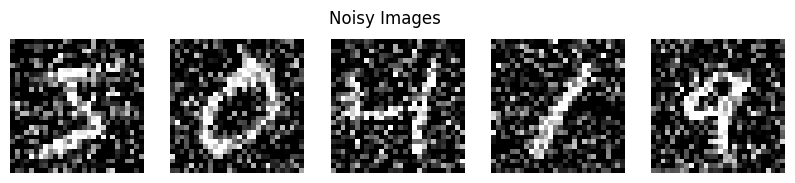

In [19]:
n = 5
plt.figure(figsize=(10,2))
for i in range(n):
    ax = plt.subplot(1, n, i+1)
    plt.imshow(x_train_noisy[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle("Noisy Images")
plt.show()

Cell 6 — Build the autoencoder model

In [20]:
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

Cell 7 — Compile the model

In [21]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

Cell 8 — Train the model

In [22]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[early_stop]
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 124s 522ms/step - loss: 0.2075 - val_loss: 0.1142
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 117s 497ms/step - loss: 0.1076 - val_loss: 0.1018
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 116s 492ms/step - loss: 0.1007 - val_loss: 0.0977
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 142s 491ms/step - loss: 0.0977 - val_loss: 0.0958
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 143s 494ms/step - loss: 0.0956 - val_loss: 0.0937
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 116s 494ms/step - loss: 0.0942 - val_loss: 0.0925
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 115s 488ms/step - loss: 0.0931 - val_loss: 0.0918
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 145s 503ms/step - loss: 0.0922 - val_loss: 0.0911
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 141s 496ms/step - loss: 0.0915 - val_loss: 0.0909
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 118s 502ms/step - loss: 0.0908 - val_loss: 0.0898


Cell 9 — Plot training loss

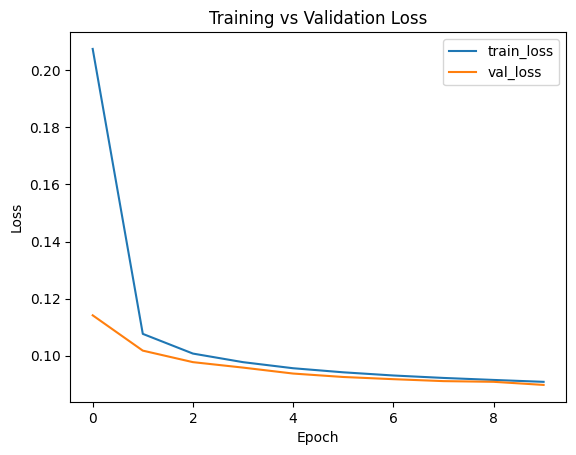

In [23]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

Cell 10 — Denoise test images

In [24]:
decoded_imgs = autoencoder.predict(x_test_noisy[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step


Cell 11 — Compare original, noisy, and denoised images

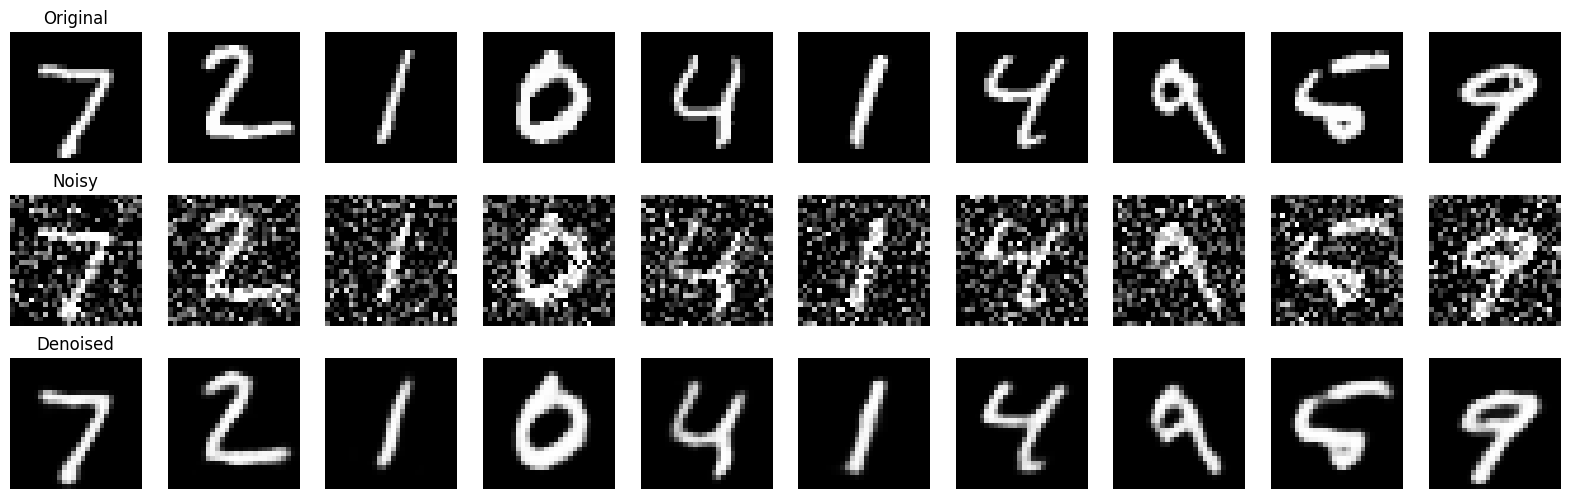

In [25]:
n = 10
plt.figure(figsize=(20, 6))

for i in range(n):
    # original
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0: ax.set_title("Original")

    # noisy
    ax = plt.subplot(3, n, i+1+n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0: ax.set_title("Noisy")

    # denoised
    ax = plt.subplot(3, n, i+1+2*n)
    plt.imshow(decoded_imgs[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0: ax.set_title("Denoised")

plt.show()

Cell 12 — Evaluate with PSNR

In [26]:
from skimage.metrics import peak_signal_noise_ratio as psnr

scores = [psnr(x_test[i], decoded_imgs[i]) for i in range(10)]
print("Average PSNR:", np.mean(scores))

Average PSNR: 21.690403598247578
